# <span style="color:green">Tarea final programación Python avanzado</span>

### <span style="color:blue">Alumno: Nicolas Esteban Spector</span>

### Importacion de librerias

In [1]:
import random

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

### Inicialización de variables

In [2]:
hostnames = []
dataset = []
df = None

### Función para generar hostnames

In [3]:
def set_hostnames(number_of_hosts: int) -> None:
        so_prefix = ['L']*4 + ['S']*3 + ['A']*2 + ['H']*1  # Linux: 40% | Solaris: 30% | AIX: 20% | HP-UX: 10%
        environments = ['D']*10 + ['I']*10 + ['T']*25 + ['S']*25 + ['P']*30  # Development: 10% | Integration: 10% | Testing: 25% | Staging: 25% | Production: 30%
        countries = ['NOR']*6 + ['FRA']*9 + ['ITA']*16 + ['ESP']*16 + ['DEU']*23 + ['IRL']*30  # Norway: 6% | France: 9% | Italy: 16% | Spain: 16% | Germany: 23% | Ireland: 30%
        grupo_alpha = []
        
        for i in range(number_of_hosts):
            country = random.choice(countries)
            so = random.choice(so_prefix) + random.choice(environments)
            so += country
            grupo_alpha.append(so)
            so += str(grupo_alpha.count(so)).zfill(3)
            hostnames.append(so)

### Función para obtener el nombre del sistema operativo

In [4]:
def get_os(hostname: str) -> str:
    if hostname.startswith('L'):
        return 'Linux'
    elif hostname.startswith('S'):
        return 'Solaris'
    elif hostname.startswith('A'):
        return 'AIX'
    elif hostname.startswith('H'):
        return 'HP-UX'
    else:
        return 'Unknow'

### Función para obtener el nombre del entorno

In [5]:
def get_enviroment(hostname: str) -> str:
    if hostname[1] == 'D':
        return 'Development'
    elif hostname[1] == 'I':
        return 'Integration'
    elif hostname[1] == 'T':
        return 'Testing'
    elif hostname[1] == 'S':
        return 'Staging'
    elif hostname[1] == 'P':
        return 'Production'
    else:
        return 'Unknow'

### Función para obtener el nombre del pais

In [6]:
def get_country(hostname: str) -> str:
    if hostname[2:5] == 'NOR':
        return 'Norway'
    elif hostname[2:5] == 'FRA':
        return 'France'
    elif hostname[2:5] == 'ITA':
        return 'Italy'
    elif hostname[2:5] == 'ESP':
        return 'Spain'
    elif hostname[2:5] == 'DEU':
        return 'Germany'
    elif hostname[2:5] == 'IRL':
        return 'Ireland'
    else:
        return 'Unknow'

### Función para generar el DataFrame

In [7]:
def set_dataframe(count: int) -> None:
    global df
    
    set_hostnames(count)
    
    for hostname in hostnames:
        dataset.append({
            'hostname': hostname,
            'os': get_os(hostname),
            'enviroment': get_enviroment(hostname),
            'country': get_country(hostname),
            'node': int(hostname[-3:])
        })
        
    df = pd.DataFrame(dataset)

### Creación e inspección del DataFrame

In [8]:
set_dataframe(1500)

In [9]:
df

,hostname,os,enviroment,country,node
0,SSITA001,Solaris,Staging,Italy,1
1,SSDEU001,Solaris,Staging,Germany,1
2,APIRL001,AIX,Production,Ireland,1
3,LTITA001,Linux,Testing,Italy,1
4,STDEU001,Solaris,Testing,Germany,1
...,...,...,...,...,...
1495,HTDEU012,HP-UX,Testing,Germany,12
1496,STESP024,Solaris,Testing,Spain,24
1497,SIIRL020,Solaris,Integration,Ireland,20
1498,APITA010,AIX,Production,Italy,10


### Guardado y lectura del DataFrame en un archivo CSV

In [10]:
df.to_csv(r'hosts.csv', header=True, index=False, encoding='utf-8')

hosts_df = pd.read_csv('hosts.csv', encoding='utf-8')

In [11]:
hosts_df

,hostname,os,enviroment,country,node
0,SSITA001,Solaris,Staging,Italy,1
1,SSDEU001,Solaris,Staging,Germany,1
2,APIRL001,AIX,Production,Ireland,1
3,LTITA001,Linux,Testing,Italy,1
4,STDEU001,Solaris,Testing,Germany,1
...,...,...,...,...,...
1495,HTDEU012,HP-UX,Testing,Germany,12
1496,STESP024,Solaris,Testing,Spain,24
1497,SIIRL020,Solaris,Integration,Ireland,20
1498,APITA010,AIX,Production,Italy,10


### Generación de un gráfico de barras agrupado por país y entorno

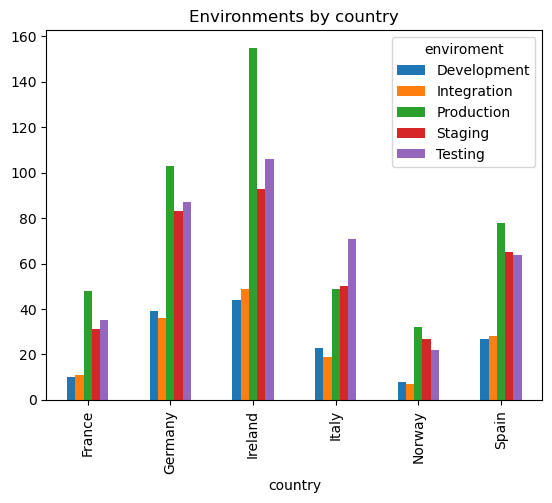

In [12]:
# Agrupo el DataFrame por país y entorno y lo desapilo
df_grouped_unstacked = df.groupby(['country', 'enviroment']).size().unstack()

# Genero un gráfico de barras
df_grouped_unstacked.plot(kind='bar', title='Environments by country');

### Creación de una figura con 4 gráficos en una malla de 2 filas y 2 columnas

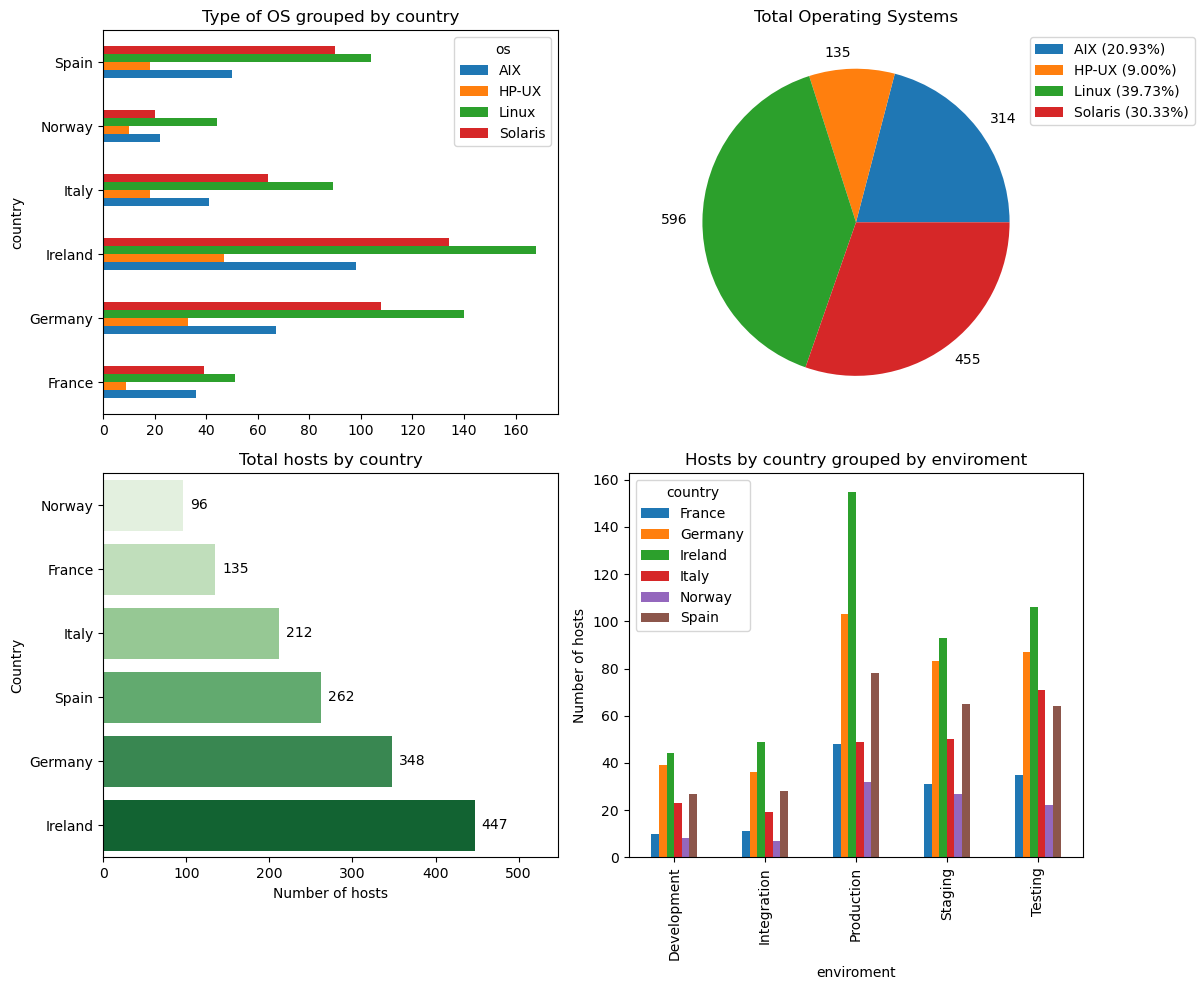

In [13]:
# Creación de figura y ejes

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Type of OS grouped by country

df.groupby(['country', 'os']).size().unstack().plot(kind='barh', stacked=False, ax=axs[0, 0])
axs[0, 0].set_title('Type of OS grouped by country')

# Gráfico 2: Total Operating Systems

## Agrupo por el tipo de sistema operativo y cuento el número de ocurrencias de cada tipo
os_counts_grouped = df.groupby('os').size()

## Creo el gráfico de torta

pie = os_counts_grouped.plot(kind='pie', ax=axs[0, 1], autopct='', labels=os_counts_grouped.values, legend=True)
axs[0, 1].set_ylabel('')
axs[0, 1].set_title('Total Operating Systems')
axs[0, 1].legend(labels=[f'{os} ({count/sum(os_counts_grouped)*100:.2f}%)' for os, count in os_counts_grouped.items()], loc='upper right', bbox_to_anchor=(1.4, 1))

# Gráfico 3: Total hosts by country

country_counts = df['country'].value_counts()
max_hosts = country_counts.max() + 100
barplot = sns.barplot(x=country_counts.values, y=country_counts.index, ax=axs[1, 0], palette='Greens_r')
axs[1, 0].set_title('Total hosts by country')
axs[1, 0].set_xlabel('Number of hosts')
axs[1, 0].set_ylabel('Country')
axs[1, 0].set_xlim(0, max_hosts)
axs[1, 0].invert_yaxis()

## Agrego etiquetas con la cantidad en cada barra
for patch in barplot.patches:
    width = patch.get_width()
    axs[1, 0].annotate(f'{int(width)}', xy=(width, patch.get_y() + patch.get_height() / 2),
                       xytext=(5, 0), textcoords='offset points',
                       ha='left', va='center')    
    
# Gráfico 4: Hosts by country grouped by enviroment

df.groupby(['country', 'enviroment']).size().unstack(0).plot(kind='bar', stacked=False, ax=axs[1, 1])
axs[1, 1].set_title('Hosts by country grouped by enviroment')
axs[1, 1].set_ylabel('Number of hosts')

# Ajusto los márgenes y espacios entre los gráficos y

fig.tight_layout()